In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel(r"C:\Users\Lenovo\Downloads\EastWestAirlines.xlsx",sheet_name='data')
df

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...,...
3994,4017,18476,0,1,1,1,8525,4,200,1,1403,1
3995,4018,64385,0,1,1,1,981,5,0,0,1395,1
3996,4019,73597,0,3,1,1,25447,8,0,0,1402,1
3997,4020,54899,0,1,1,1,500,1,500,1,1401,0


Data Preprocessing:

1.	Preprocess the dataset to handle missing values, remove outliers, and scale the features if necessary


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB


In [5]:
df.isnull().sum()

ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_miles_12mo    0
Flight_trans_12      0
Days_since_enroll    0
Award?               0
dtype: int64

In [6]:
df = df.drop('ID#', axis=1)
df

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1
...,...,...,...,...,...,...,...,...,...,...,...
3994,18476,0,1,1,1,8525,4,200,1,1403,1
3995,64385,0,1,1,1,981,5,0,0,1395,1
3996,73597,0,3,1,1,25447,8,0,0,1402,1
3997,54899,0,1,1,1,500,1,500,1,1401,0


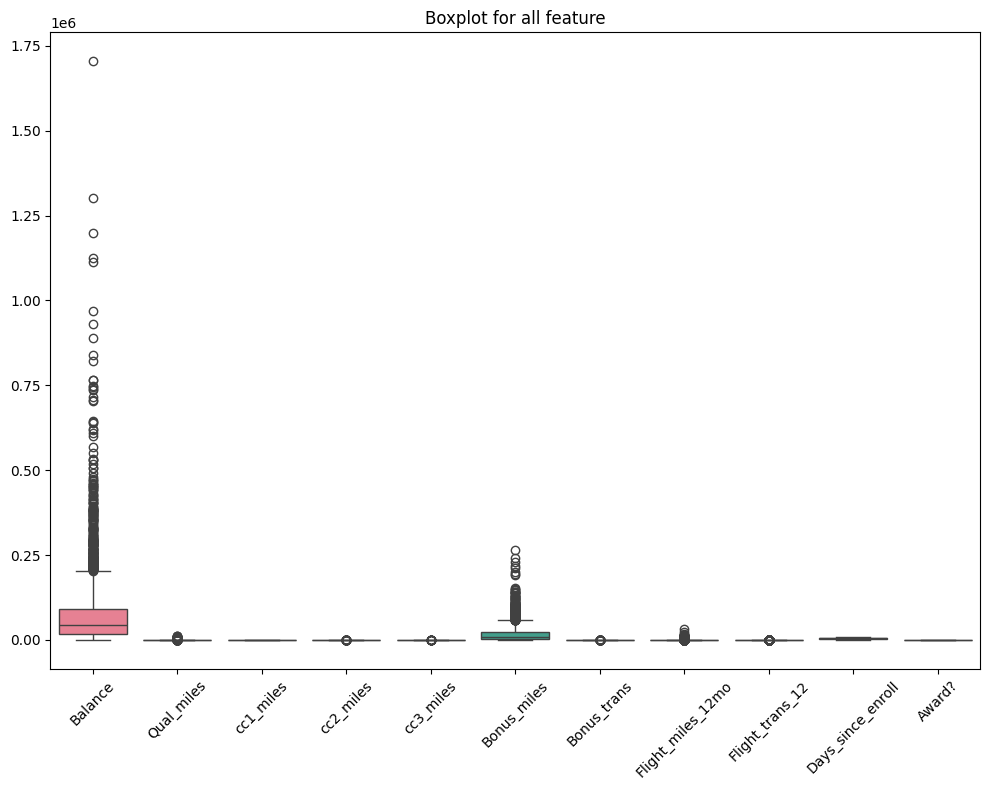

In [7]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df)
plt.title("Boxplot for all feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination=0.01, random_state=42)
outlier_predictions = iso_forest.fit_predict(df)

outlier_indices = df.index[outlier_predictions == -1]

print(f"Number of detected outliers: {len(outlier_indices)}")


Number of detected outliers: 40


In [9]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

mask = ~((df[num_cols] < (Q1 - 1.5 * IQR)) | 
         (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[mask]

print("After removing outliers:", df.shape)
    


After removing outliers: (2875, 11)


In [10]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()
df_scalar = scalar.fit_transform(df)
df_scalar = pd.DataFrame(df_scalar, columns = df.columns)
df_scalar

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693,-0.623072
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035,-0.623072
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330,-0.623072
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206,-0.623072
4,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312,-0.623072
...,...,...,...,...,...,...,...,...,...,...,...
2870,-0.665761,0.0,-0.719055,0.0,0.0,-0.171862,-0.694742,0.948432,1.653181,-1.235018,1.604952
2871,0.411806,0.0,-0.719055,0.0,0.0,-0.724061,-0.565745,-0.378837,-0.409708,-1.238933,1.604952
2872,0.628028,0.0,1.013789,0.0,0.0,1.066780,-0.178756,-0.378837,-0.409708,-1.235507,1.604952
2873,0.189152,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,2.939335,1.653181,-1.235997,-0.623072


2.	Perform exploratory data analysis (EDA) to gain insights into the distribution of data and identify potential clusters.

In [11]:
df_scalar.describe()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,2.875000e+03,2875.0,2.875000e+03,2875.0,2875.0,2.875000e+03,2.875000e+03,2.875000e+03,2.875000e+03,2.875000e+03,2.875000e+03
mean,-7.908650e-17,0.0,-7.908650e-17,0.0,0.0,-5.931487e-17,8.402940e-17,1.482872e-17,2.965744e-17,-7.908650e-17,9.885812e-18
std,1.000174e+00,0.0,1.000174e+00,0.0,0.0,1.000174e+00,1.000174e+00,1.000174e+00,1.000174e+00,1.000174e+00,1.000174e+00
min,-1.098253e+00,0.0,-7.190547e-01,0.0,0.0,-7.958670e-01,-1.210728e+00,-3.788372e-01,-4.097077e-01,-1.917616e+00,-6.230716e-01
25%,-7.408945e-01,0.0,-7.190547e-01,0.0,0.0,-7.592685e-01,-9.527351e-01,-3.788372e-01,-4.097077e-01,-8.672958e-01,-6.230716e-01
50%,-3.171815e-01,0.0,-7.190547e-01,0.0,0.0,-4.664800e-01,-4.975903e-02,-3.788372e-01,-4.097077e-01,-5.967701e-02,-6.230716e-01
75%,4.492551e-01,0.0,1.013789e+00,0.0,0.0,4.549983e-01,7.242205e-01,-3.788372e-01,-4.097077e-01,8.020114e-01,1.604952e+00
max,3.656806e+00,0.0,2.746632e+00,0.0,0.0,3.404329e+00,3.691142e+00,4.711239e+00,3.716071e+00,2.137849e+00,1.604952e+00


In [12]:
stats = pd.DataFrame({
    'Skewness': df_scalar.skew(),
    'Variance': df_scalar.var()
})

print(stats)


                   Skewness  Variance
Balance            1.362606  1.000348
Qual_miles         0.000000  0.000000
cc1_miles          0.967719  1.000348
cc2_miles          0.000000  0.000000
cc3_miles          0.000000  0.000000
Bonus_miles        1.443024  1.000348
Bonus_trans        0.570622  1.000348
Flight_miles_12mo  2.669772  1.000348
Flight_trans_12    2.443846  1.000348
Days_since_enroll  0.202496  1.000348
Award?             0.982393  1.000348


In [13]:
df_scalar[['Qual_miles','cc2_miles','cc3_miles']].var()


Qual_miles    0.0
cc2_miles     0.0
cc3_miles     0.0
dtype: float64

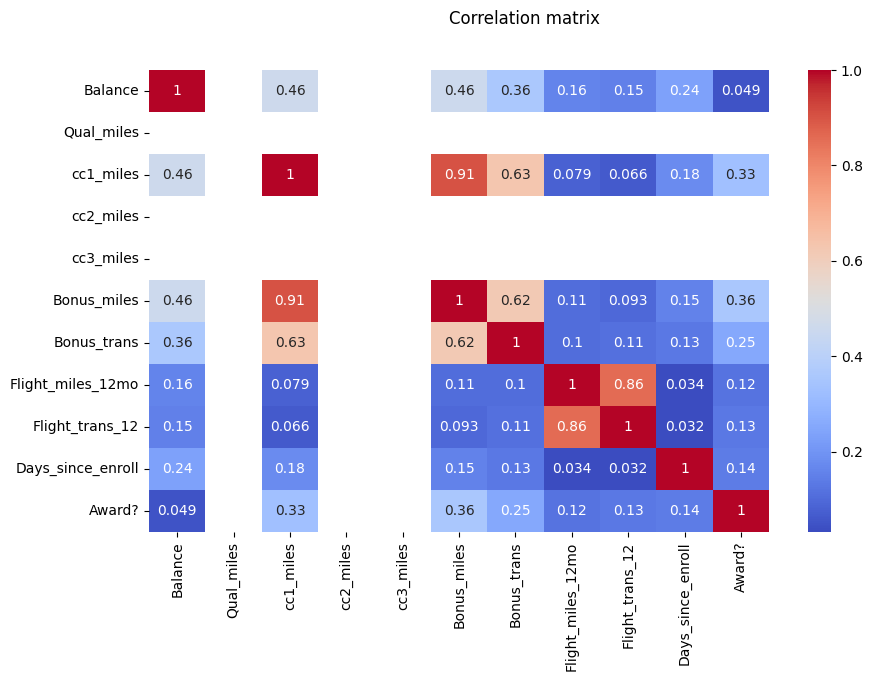

In [14]:
plt.figure(figsize = (10,6))
sns.heatmap(df_scalar.corr(), annot = True, cmap = 'coolwarm')   
plt.suptitle("Correlation matrix")
plt.show()

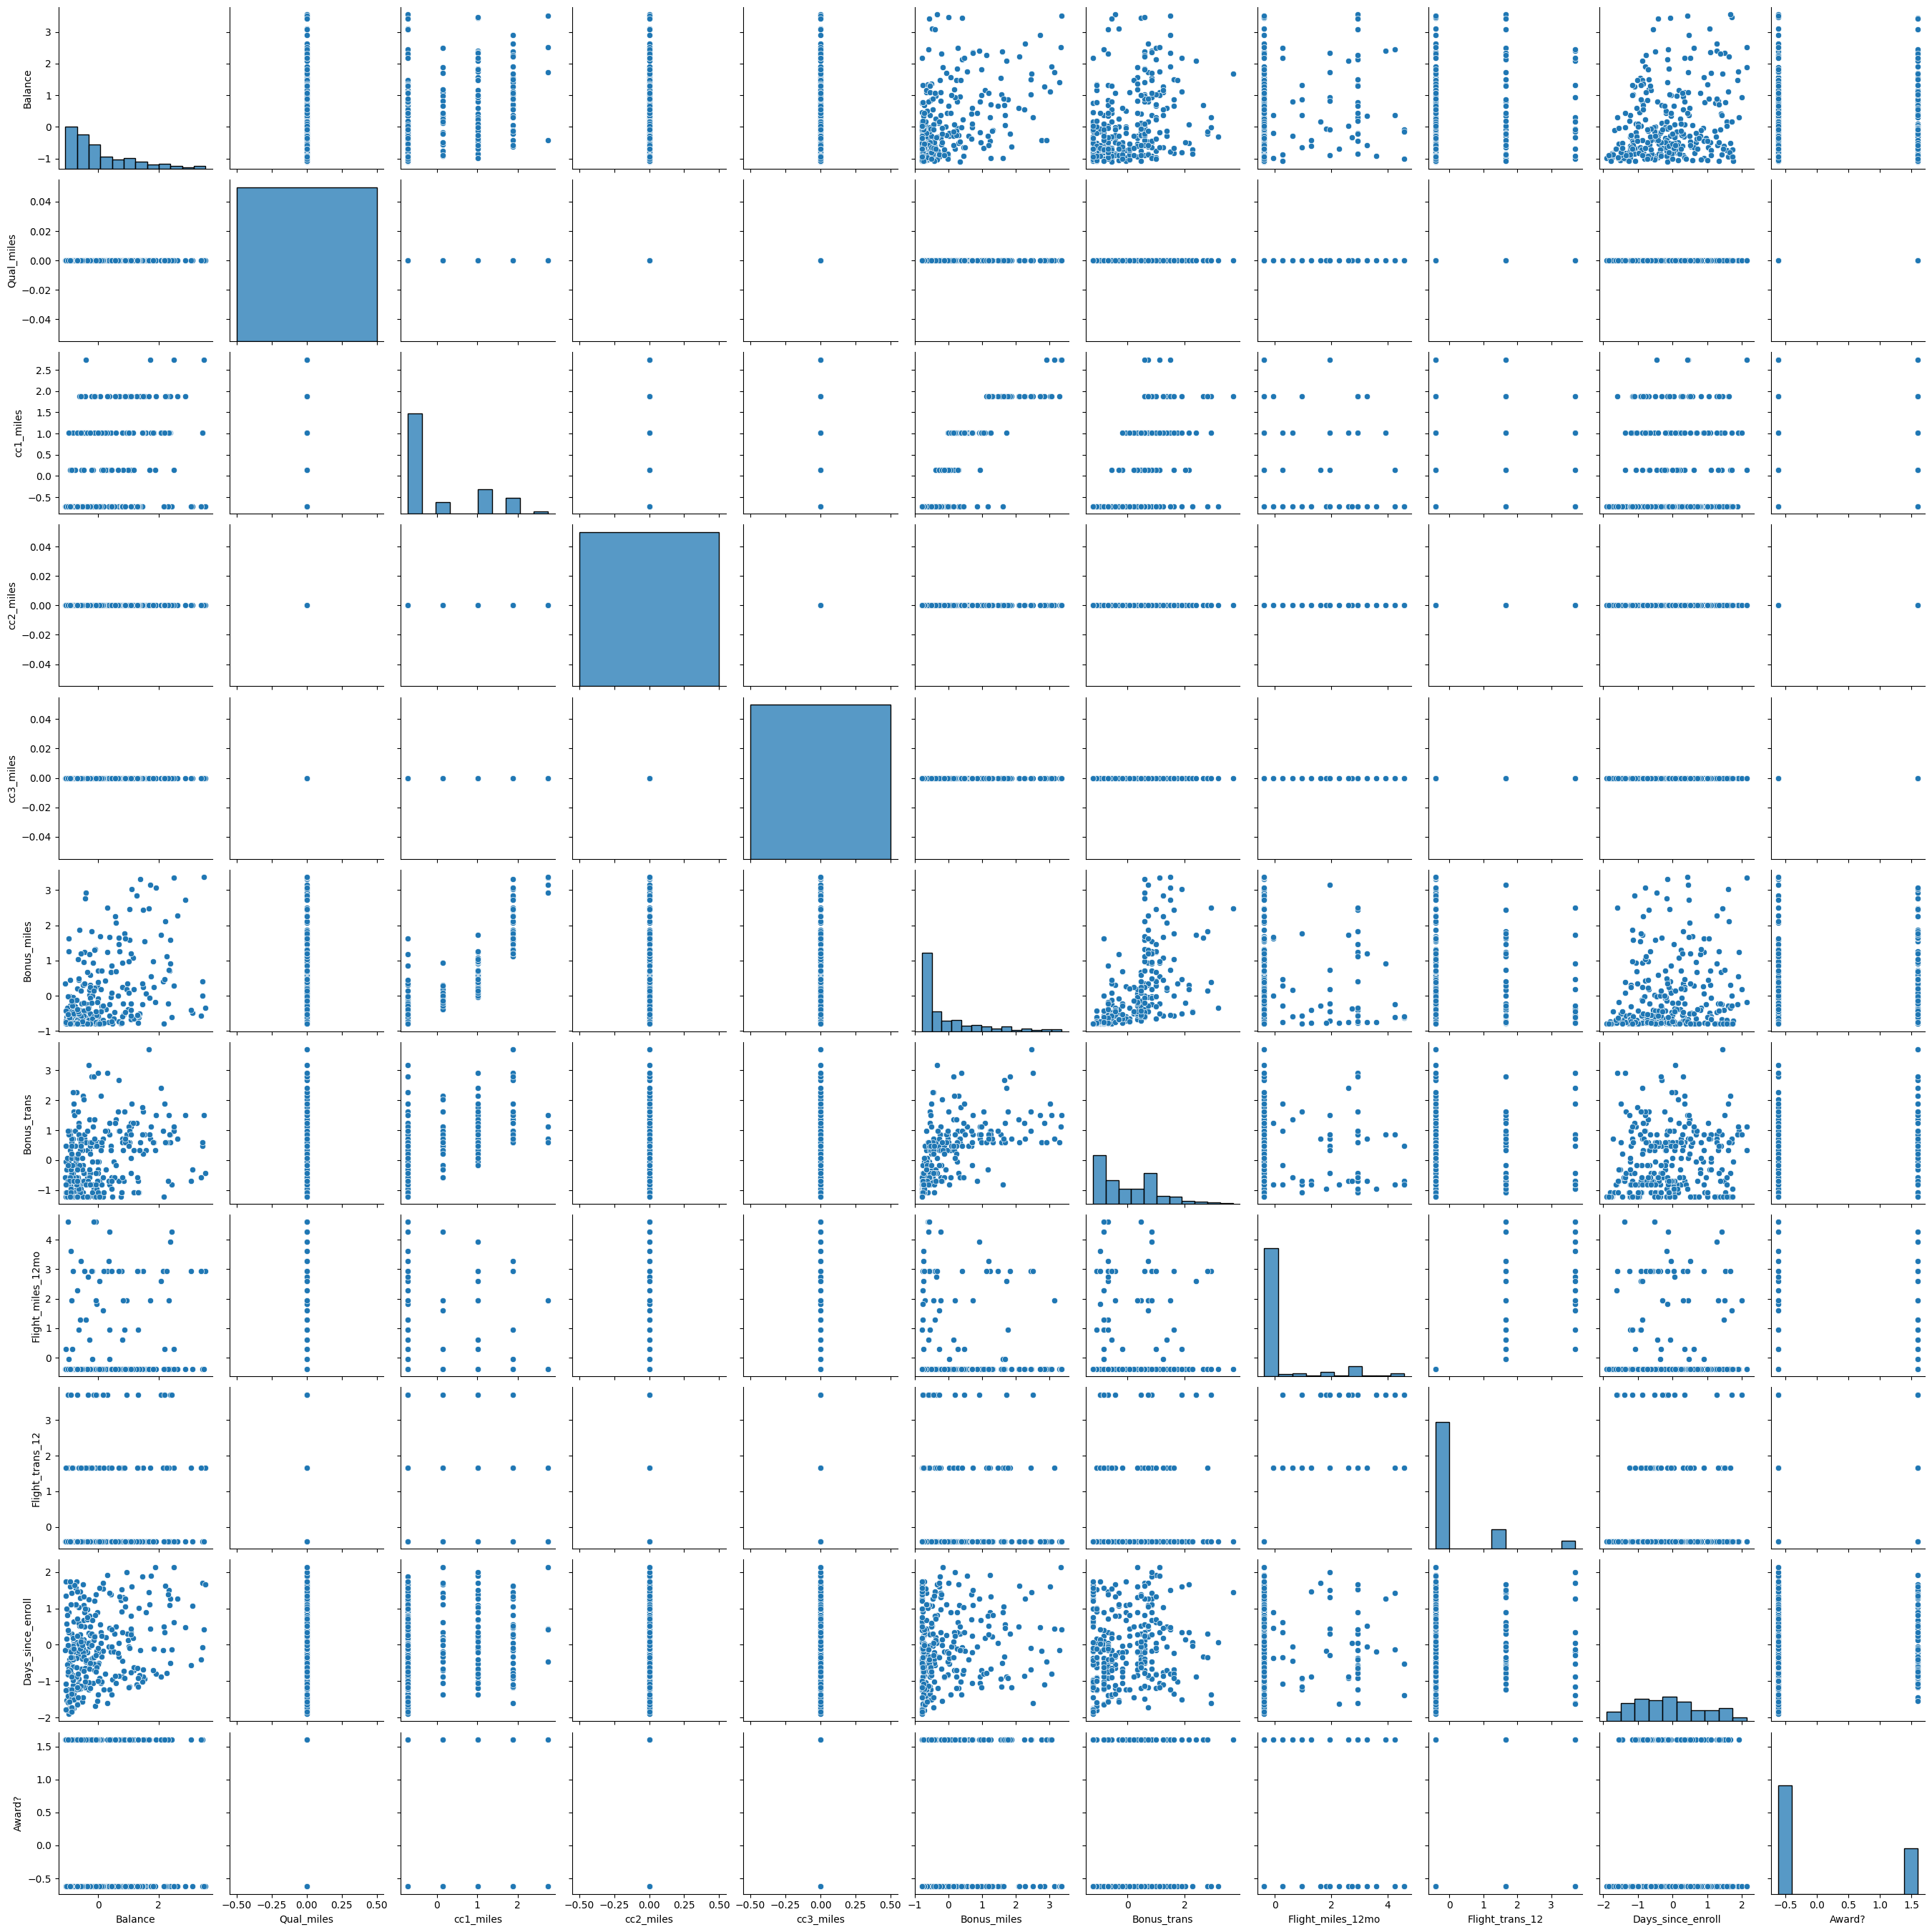

In [67]:
sns.pairplot(df_scalar.sample(300))   
plt.show()


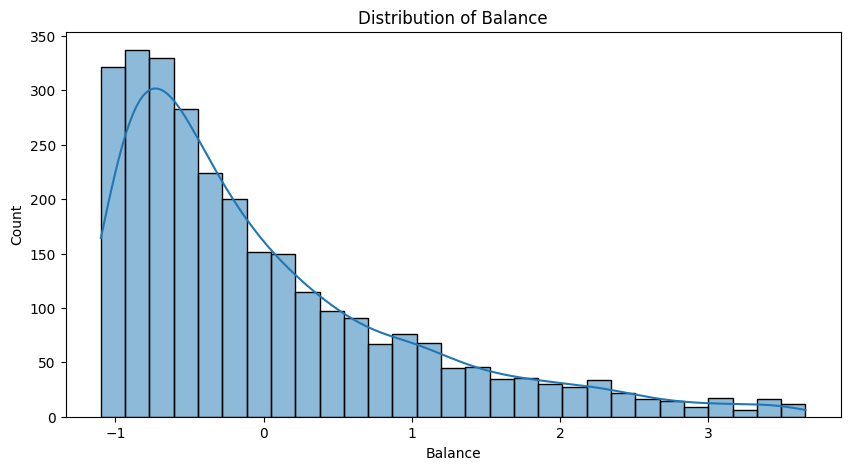

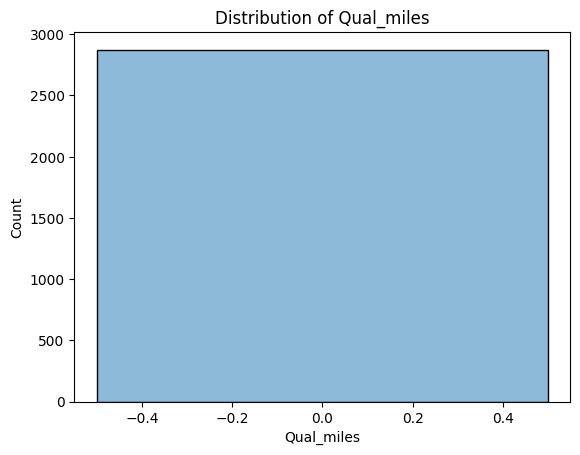

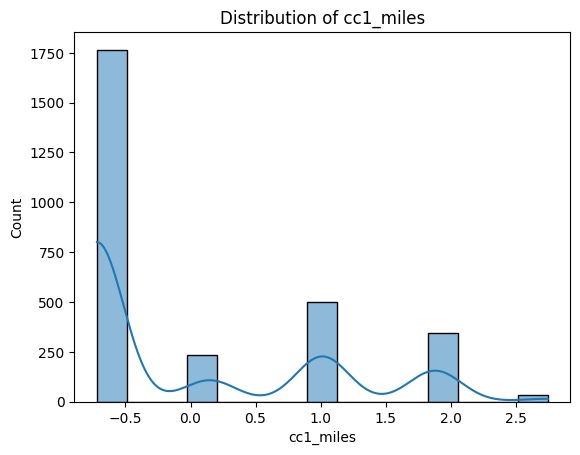

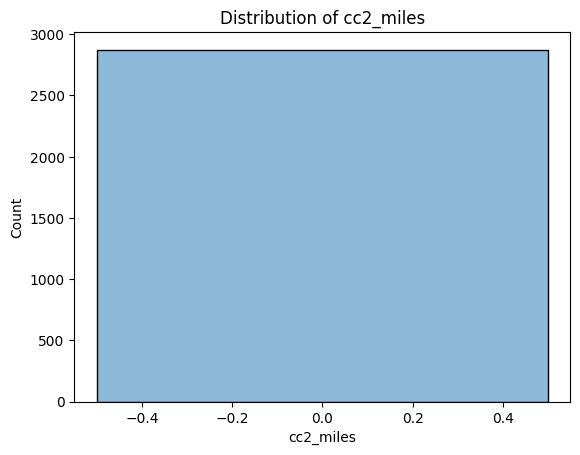

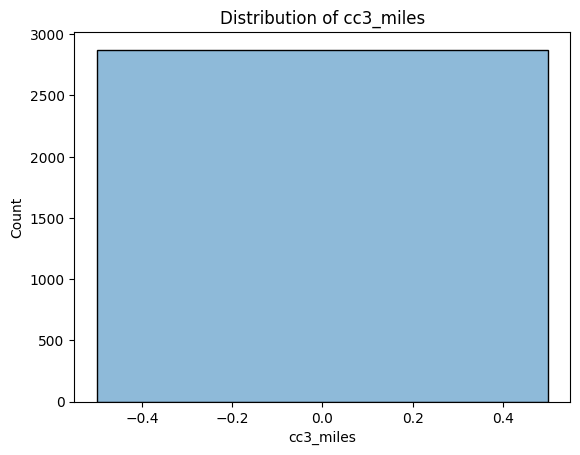

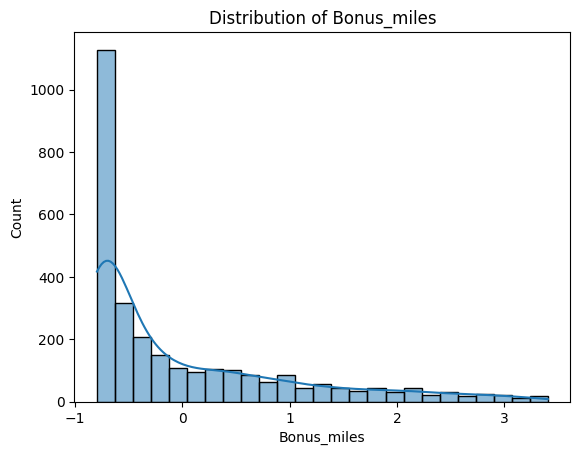

In [15]:
plt.figure(figsize=(10,5))
for col in df_scalar.columns[:6]:  
    sns.histplot(df_scalar[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


3.	Use multiple visualizations to understand the hidden patterns in the dataset

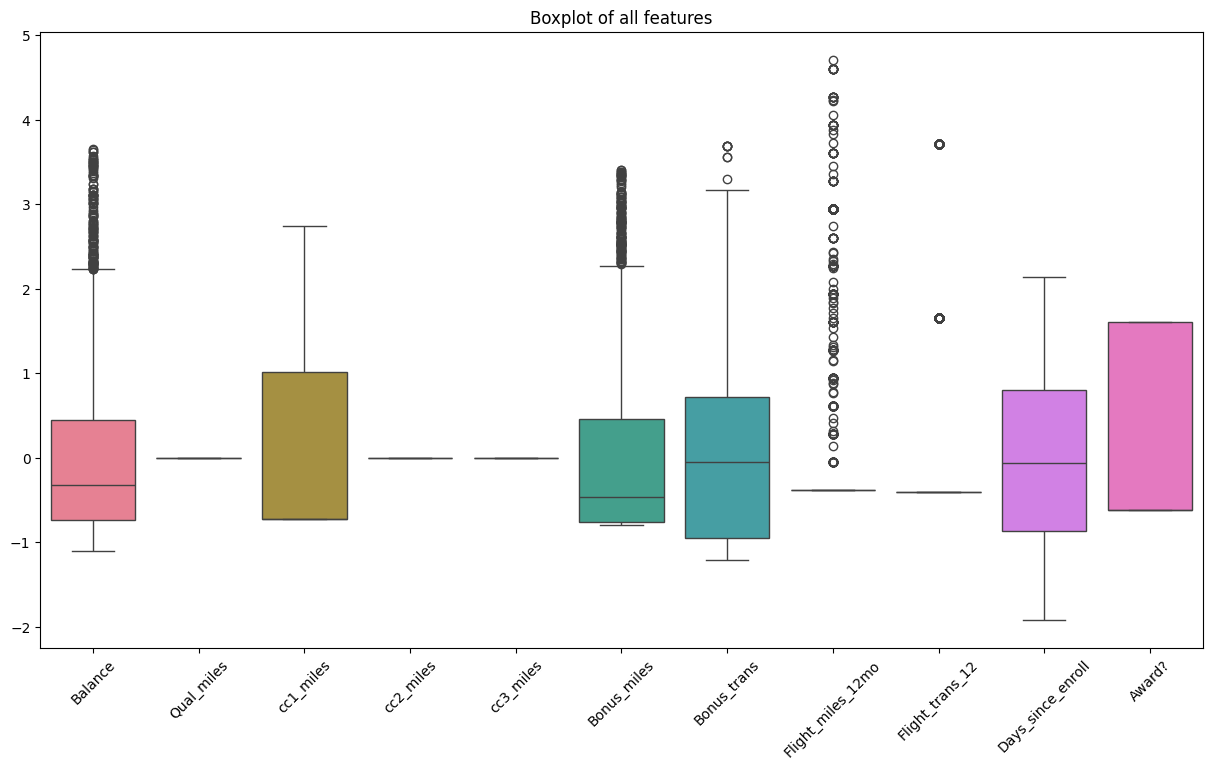

In [16]:
plt.figure(figsize = (15,8))
sns.boxplot(data=df_scalar)
plt.title("Boxplot of all features")
plt.xticks(rotation=45)
plt.show()

Implementing Clustering Algorithms:

•	Implement the K-Means and DBSCAN algorithms using a programming language such as Python with libraries like scikit-learn.


In [17]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

•	Apply each clustering algorithm to the pre-processed dataset to identify clusters within the data

In [18]:
kmean = KMeans(n_clusters = 10, n_init=30) 
kmean.fit(df_scalar)

KMeans(n_clusters=10, n_init=30)

In [19]:
kmean_label  = kmean.predict(df_scalar)
kmean_label  = pd.DataFrame(kmean_label)
kmean_label

,0
0,5
1,5
2,5
3,5
4,5
...,...
2870,6
2871,4
2872,8
2873,6


In [20]:
kmean_c = kmean.cluster_centers_
kmean_c

array([[ 2.04222172,  0.        ,  0.08995354,  0.        ,  0.        ,
        -0.0361944 ,  0.33412237, -0.32186857, -0.27301025,  0.69443811,
        -0.24726043],
       [ 0.89084778,  0.        ,  1.42869489,  0.        ,  0.        ,
         1.42104128,  1.13664615,  2.56727934,  2.21974958,  0.23365169,
         0.6321529 ],
       [-0.24213209,  0.        , -0.20030537,  0.        ,  0.        ,
        -0.20357517,  0.94031028, -0.35347537, -0.32430149, -0.58243811,
        -0.62307163],
       [ 0.56439514,  0.        ,  1.92746979,  0.        ,  0.        ,
         2.17028589,  1.05961158, -0.33459489, -0.25967942,  0.45778974,
         1.60495191],
       [-0.38935484,  0.        , -0.69962817,  0.        ,  0.        ,
        -0.46227171, -0.52525316, -0.3364003 , -0.28019899,  0.06332604,
         1.60495191],
       [-0.48663701,  0.        , -0.68645662,  0.        ,  0.        ,
        -0.66710852, -0.7353567 , -0.36505199, -0.36477351,  0.83874603,
        -0.623

In [21]:
kmean_c.shape

(10, 11)

In [22]:
kmean.inertia_

6846.472046084411

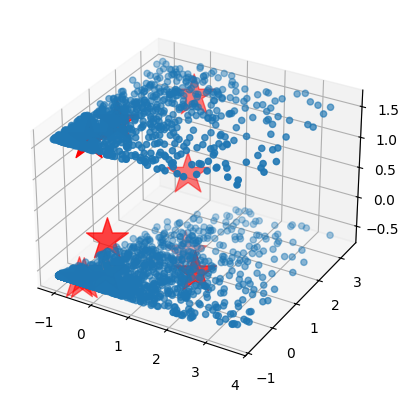

In [23]:
#visualization
%matplotlib inline
fig = plt.figure()
ax = fig.add_subplot(111, projection = '3d')
ax.scatter(df_scalar.iloc[:,0], df_scalar.iloc[:,5], df_scalar.iloc[:,10])
ax.scatter(kmean_c[:,0], kmean_c[:,5], kmean_c[:,10], marker="*", c='Red', s=1000)
plt.show()

•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.

In [24]:
#DBSCAN
dbscan = DBSCAN(eps=2, min_samples= 5)
dbscan.fit(df_scalar)

DBSCAN(eps=2)

In [25]:
dbscan.labels_

array([0, 0, 0, ..., 2, 3, 0])

In [26]:
dbscan_c = pd.DataFrame(dbscan.labels_, columns=['cluster'])
dbscan_c

,cluster
0,0
1,0
2,0
3,0
4,0
...,...
2870,1
2871,2
2872,2
2873,3


In [27]:
print(dbscan_c['cluster'].value_counts())

cluster
 0    1805
 2     608
 3     204
 1     146
 4      55
 5      27
-1      23
 6       7
Name: count, dtype: int64


In [28]:
print(set(dbscan.labels_))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(-1)}


•	Experiment with different parameter settings for K-means (Elbow curve for different K values) and DBSCAN (e.g., epsilon, minPts) and evaluate the clustering results.



In [29]:
#K-Means Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
inertia_list = []
silhouette_list = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scalar)
    
    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(df_scalar, kmeans.labels_))


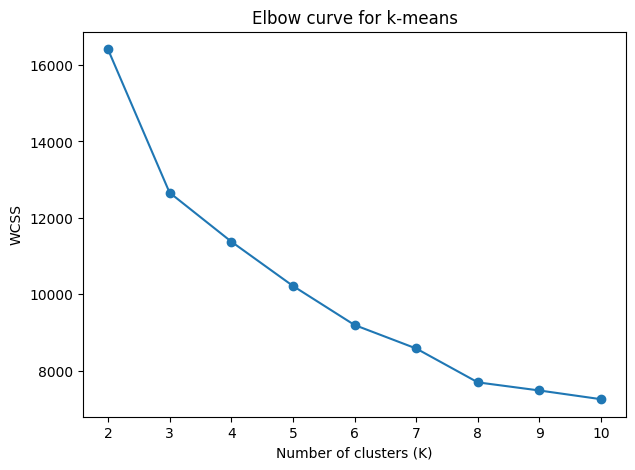

In [30]:
plt.figure(figsize =(7,5))
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow curve for k-means")
plt.xlabel("Number of clusters (K)")
plt.ylabel("WCSS")
plt.show()

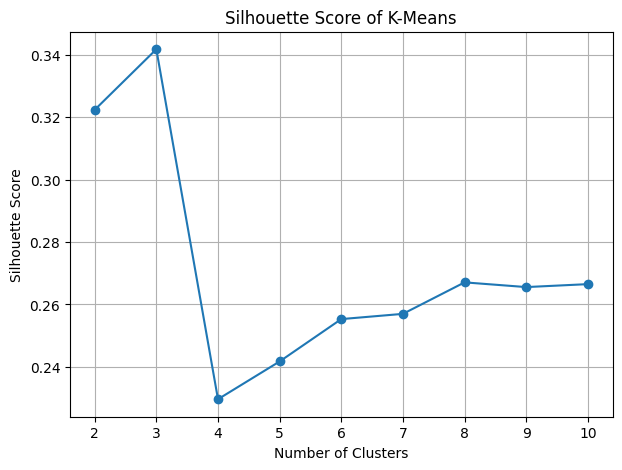

In [55]:
plt.figure(figsize=(7,5))
plt.plot(K_range, silhouette_list, marker='o')
plt.title("Silhouette Score of K-Means")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [31]:
inertia_list

[16416.789022423716,
 12660.34318319643,
 11379.380926227057,
 10218.00216465312,
 9194.244627420525,
 8578.48689033132,
 7691.265843762775,
 7478.45964979008,
 7249.845411739927]

In [40]:
#DBSCAN
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3,5,7]
silhouette_Scores = []
eps_score = []

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(df_scalar)
        if len(set(labels)) <=1:
            continue
        score = silhouette_score(df_scalar, labels)
        eps_score.append(eps)
        silhouette_Scores.append(score)

In [41]:
eps_score

[0.2, 0.2, 0.2, 0.3, 0.3, 0.3, 0.4, 0.4, 0.4, 0.5, 0.5, 0.5, 0.6, 0.6, 0.6]

Cluster Analysis and Interpretation:

•	Analyse the clusters generated by each clustering algorithm and interpret the characteristics of each cluster. Write you insights in few comments.

-> Clustering helps us clearly see the difference between customers who travel a lot and customers who travel very less.
K-Means makes clean and well-separated groups, which is helpful for dividing customers into proper categories.

DBSCAN can find outliers (unusual customers) that K-Means cannot detect.

Visualization:

Visualize the clustering results using scatter plots or other suitable visualization techniques.
Plot the clusters with different colours to visualize the separation of data points belonging to different clusters.

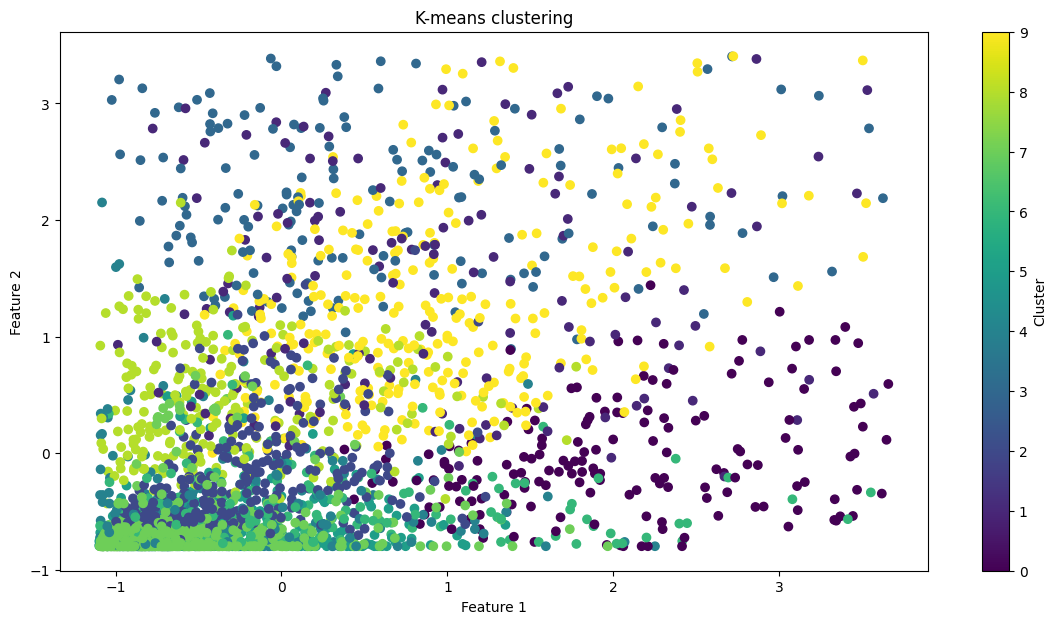

In [34]:
plt.figure(figsize=(14,7))
plt.scatter(df_scalar.iloc[:,0],df_scalar.iloc[:,5], c=kmean_label, cmap='viridis')
plt.title("K-means clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Cluster")
plt.show()

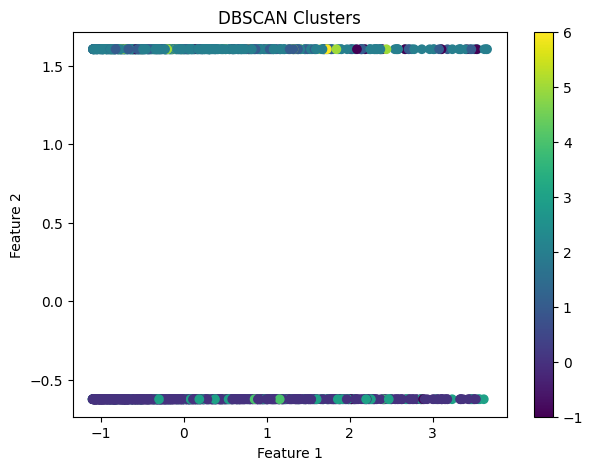

In [42]:
plt.figure(figsize=(7,5))
plt.scatter(df_scalar.iloc[:,0],df_scalar.iloc[:,10], c=dbscan_c.to_numpy(), cmap='viridis')
plt.title("DBSCAN Clusters")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar()
plt.show()


Evaluation and Performance Metrics:

Evaluate the quality of clustering using internal evaluation metrics such as silhouette score for K-Means and DBSCAN.


In [38]:
# Silhouette score for K-Means

print("K-Means Silhouette Score:", silhouette_list)


K-Means Silhouette Score: [np.float64(0.32241400527279074), np.float64(0.34184773367504273), np.float64(0.22962827467448732), np.float64(0.24173542157075825), np.float64(0.2553188320125063), np.float64(0.2569959214101372), np.float64(0.2670945242863072), np.float64(0.2655848183874808), np.float64(0.26652735755014567)]


In [43]:
print("Silhouette Score of DBSCAN.", silhouette_Scores)

Silhouette Score of DBSCAN. [np.float64(-0.3849818507950436), np.float64(-0.24690516706751323), np.float64(-0.24885267147980825), np.float64(-0.3873909488053238), np.float64(-0.3184814807003108), np.float64(-0.14595138665948432), np.float64(-0.2911366314967889), np.float64(-0.2750728526442334), np.float64(-0.14949095344012933), np.float64(-0.18516724241291455), np.float64(-0.12952372601527012), np.float64(-0.1251860474481334), np.float64(-0.04621968951996588), np.float64(-0.03515801615276523), np.float64(-0.07476844294276426)]
